## Cyclone Debbie Flood Mapping - SAR
This script lists the workflow for delineating flood inundation caused by Cyclone Debbie in March 2017 using SAR imagery. 
The workflow initially begins with VH and VV bands, but accuracy assessments and plots are executed for VV due to yielding higher contrast between water and land.    

Some of the script has been adapted from Digital Earth Australia's 'Radar_water_detection' ipynb notebook: https://knowledge.dea.ga.gov.au/notebooks/Real_world_examples/Radar_water_detection/

### Upload packages

In [2]:
# Upload packages needed for analysis:
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds
from rasterio.windows import from_bounds
from rasterio.features import rasterize
from rasterio.mask import mask

import geopandas as gpd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from scipy.ndimage import uniform_filter
from skimage.filters import threshold_otsu
from sklearn.metrics import confusion_matrix, cohen_kappa_score

### Upload Sentinel-1 SAR VH and VV linear gamma0 images Before and After Cyclone

In [3]:
# Import VV and VH SAR satellite images from folder:
vh_before, vh_after = "20170314_S1_VH_linear_gamma0.tiff", "20170407_S1_VH_linear_gamma0.tiff"
vv_before, vv_after = "20170314_S1_VV_linear_gamma0.tiff", "20170407_S1_VV_linear_gamma0.tiff"

# Load all four images (VV and VH):
with rasterio.open(vh_before) as src: vh_b, meta = src.read(1), src.meta
with rasterio.open(vh_after) as src:  vh_a = src.read(1)
with rasterio.open(vv_before) as src: vv_b = src.read(1)
with rasterio.open(vv_after) as src:  vv_a = src.read(1)

### Reproject to Australian Albers, Resample to 20m res, Crop to bbox

In [4]:
# Prepare uploaded SAR images to be reprojected, resampled & cropped to ROI
dst_crs = "EPSG:3577"  # destination CRS: Australian Albers
dst_res = 20  # Resolution set to 20 m for comparison with Sentinel-2 MNDWI later (which uses SWIR band)

# Study region bounding box: i.e., Rockhampton, QLD
bbox = (150.41, -23.45, 150.55, -23.29)

# Define a query for the reprojection, resampling and cropping altogether:
def reproject_resample_then_crop(src_path, out_path, crs=dst_crs, res=dst_res, bbox=bbox):
    with rasterio.open(src_path) as src: 
        
        # Calculate the default transform for reprojection - maps raster from original crs to new crs:
        transform, width, height = calculate_default_transform(
            src.crs, crs, src.width, src.height, *src.bounds, resolution=res
        )
        # Write to metadata:
        profile = src.meta.copy()
        profile.update({
            'crs': crs,
            'transform': transform,
            'width': width,
            'height': height
        })
        # Resampling using bilinear to 20 m resolution:
        with rasterio.open(out_path, 'w', **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=crs,
                resampling=Resampling.bilinear
            )
        # Crop to the bbox
        with rasterio.open(out_path, 'r+') as dst:
            
        # Transform bbox to destination CRS: Australian Albers
            dst_bbox = transform_bounds("EPSG:4326", crs, *bbox)
            window = from_bounds(*dst_bbox, transform=dst.transform)
            data = dst.read(1, window=window)
            transform = dst.window_transform(window)
            profile = dst.profile.copy()
            profile.update({
                'height': data.shape[0],
                'width': data.shape[1],
                'transform': transform
            })

        # Overwrite file with updated reprojection, resampling and cropping to ROI:
        with rasterio.open(out_path, 'w', **profile) as dst_cropped:
            dst_cropped.write(data, 1)

In [5]:
# The output paths for the reprojected, resampled & cropped SAR images saved to folder:
vh_before_out = "vh_before_3577_20m_crop.tif"
vh_after_out  = "vh_after_3577_20m_crop.tif"
vv_before_out = "vv_before_3577_20m_crop.tif"
vv_after_out  = "vv_after_3577_20m_crop.tif"

# Perform the reprojection, resmapling & cropping using the query from above:
reproject_resample_then_crop(vh_before, vh_before_out)
reproject_resample_then_crop(vh_after, vh_after_out)
reproject_resample_then_crop(vv_before, vv_before_out)
reproject_resample_then_crop(vv_after, vv_after_out)

### Check data for correct projection, alignment and extent

In [6]:
# Create a dictionary of all rasters to check all at once:
rasters = {
    "VH Before": "vh_before_3577_20m_crop.tif",
    "VH After":  "vh_after_3577_20m_crop.tif",
    "VV Before": "vv_before_3577_20m_crop.tif",
    "VV After":  "vv_after_3577_20m_crop.tif"
}
# Check data to confirm reprojection, resampling & cropping to ROI have been successfully completed:
for name, path in rasters.items():
    with rasterio.open(path) as src:
        print(f"{name}")
        print(f"Shape (rows, cols): {src.height, src.width}")
        print(f"CRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        print(f"Pixel size (x, y): {src.res}")
        print(f"Dtype: {src.dtypes[0]}")
        print()

VH Before
Shape (rows, cols): (988, 830)
CRS: EPSG:3577
Bounds: BoundingBox(left=1855825.8181150467, bottom=-2665014.1073848833, right=1872425.8181150467, top=-2645254.1073848833)
Pixel size (x, y): (20.0, 20.0)
Dtype: float32

VH After
Shape (rows, cols): (988, 830)
CRS: EPSG:3577
Bounds: BoundingBox(left=1855825.8181150467, bottom=-2665014.1073848833, right=1872425.8181150467, top=-2645254.1073848833)
Pixel size (x, y): (20.0, 20.0)
Dtype: float32

VV Before
Shape (rows, cols): (988, 830)
CRS: EPSG:3577
Bounds: BoundingBox(left=1855825.8181150467, bottom=-2665014.1073848833, right=1872425.8181150467, top=-2645254.1073848833)
Pixel size (x, y): (20.0, 20.0)
Dtype: float32

VV After
Shape (rows, cols): (988, 830)
CRS: EPSG:3577
Bounds: BoundingBox(left=1855825.8181150467, bottom=-2665014.1073848833, right=1872425.8181150467, top=-2645254.1073848833)
Pixel size (x, y): (20.0, 20.0)
Dtype: float32



### Stack all four images - georeferenced

In [7]:
# Create a list only with all rasters to stack together:
rasters = [
    "vh_before_3577_20m_crop.tif",
    "vh_after_3577_20m_crop.tif",
    "vv_before_3577_20m_crop.tif",
    "vv_after_3577_20m_crop.tif"
]

stack_out = "sar_stack_3577_20m_crop.tif" # Output file name for stacked data

# Create query to stack all four rasters for further analysis:
arrays = [] # Make an empty list array for 'rasters' list created above.
for path in rasters:
    with rasterio.open(path) as src: # open each raster in loop
        arrays.append(src.read(1))   # read each raster in loop

# Pass on metatdata from example raster to other rasters ( using "vh_before_3577_20m_crop.tif"):
with rasterio.open(rasters[0]) as src0:
    meta = src0.meta.copy()
    meta.update(count=len(arrays)) # the number of raster bands the metadata needs to be allocated to

# Write stacked data to folder:
with rasterio.open(stack_out, 'w', **meta) as dst:
    for i, arr in enumerate(arrays, start=1):
        dst.write(arr, i)

### Visualise reprojected, resampled and cropped images

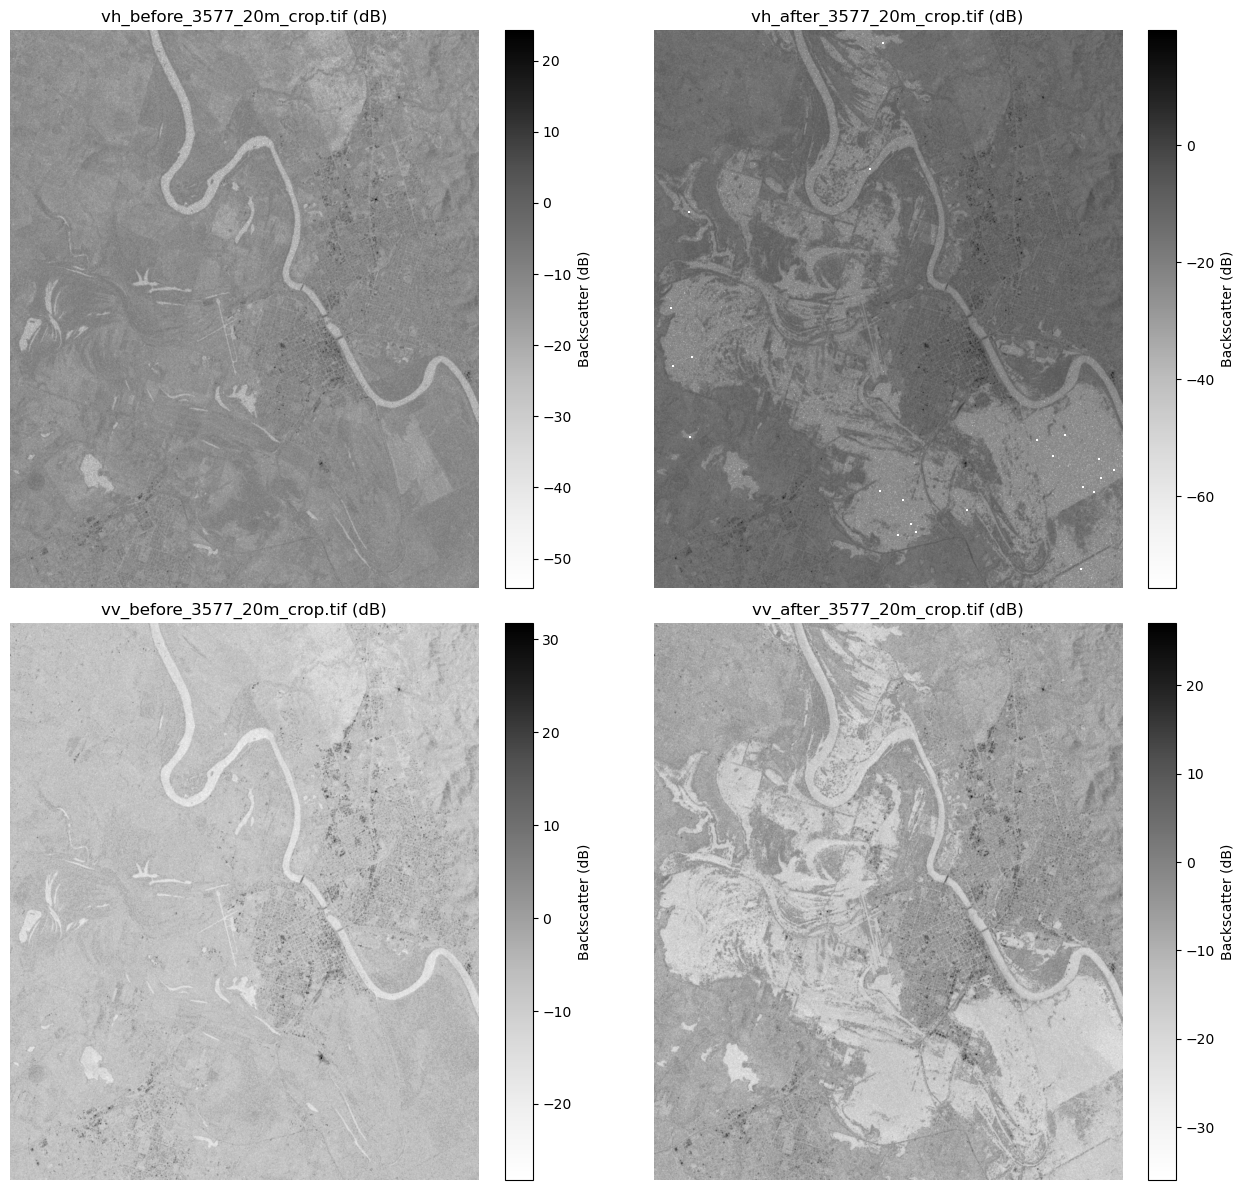

In [8]:
# Create a plot showing all four rasters: VH Before/After & VV Before/After:
fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # determine parameters for plot
axes = axes.flatten() # convert into 1D array for figure.

# Loop above parameters for each raster image:
for ax, path in zip(axes, rasters):
    with rasterio.open(path) as src:
        data = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        # Convert digital numbers (DN) to dB for visualisation
        data_db = 10 * np.log10(np.where(data > 0, data, np.nan))

        # Plot
        im = ax.imshow(data_db, cmap='Greys', extent=extent, origin='upper')
        ax.set_title(f"{os.path.basename(path)} (dB)")  # file name as title
        ax.axis('off')
        
        # Add colourbar to show backscatter (dB) range
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Backscatter (dB)")

plt.tight_layout()
plt.show()

### Apply Lee filter and convert DN to dB

In [9]:
# FOR VH:
# Define Lee filter function. adapted from 'Radar_water_detection' ipynb in DEA Sandbox.
def lee_filter(img, size):
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2
    overall_variance = np.var(img)
    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

# Define the output name for teh VH rasters:
vh_rasters = [
    "vh_before_3577_20m_crop.tif",
    "vh_after_3577_20m_crop.tif"
]

# Read in the VH rasters:
vh_arrays = []
with rasterio.open(vh_rasters[0]) as src0:
    ref_transform = src0.transform
    height = src0.height
    width = src0.width
for path in vh_rasters:
    with rasterio.open(path) as src:
        vh_arrays.append(src.read(1))

# Apply Lee filter function and convert from DN to dB:
eps = 1e-4 # ad a small number to avoid the log of zero
size = 7 # the window size to determine how 'blurred' or 'smoothed' image becomes after applied filter.
vh_filtered_dB = [] # create empty list to store the filtered images in dB

# Use loop to apply Lee filter for both VH images:
for img in vh_arrays:
    filtered_linear = lee_filter(img, size=size)
    filtered_dB = 10 * np.log10(filtered_linear + eps)
    vh_filtered_dB.append(filtered_dB)

# Map filtered images to correct crs/extent:
extent = [
    ref_transform[2],
    ref_transform[2] + ref_transform[0]*width,
    ref_transform[5] + ref_transform[4]*height,
    ref_transform[5]
]

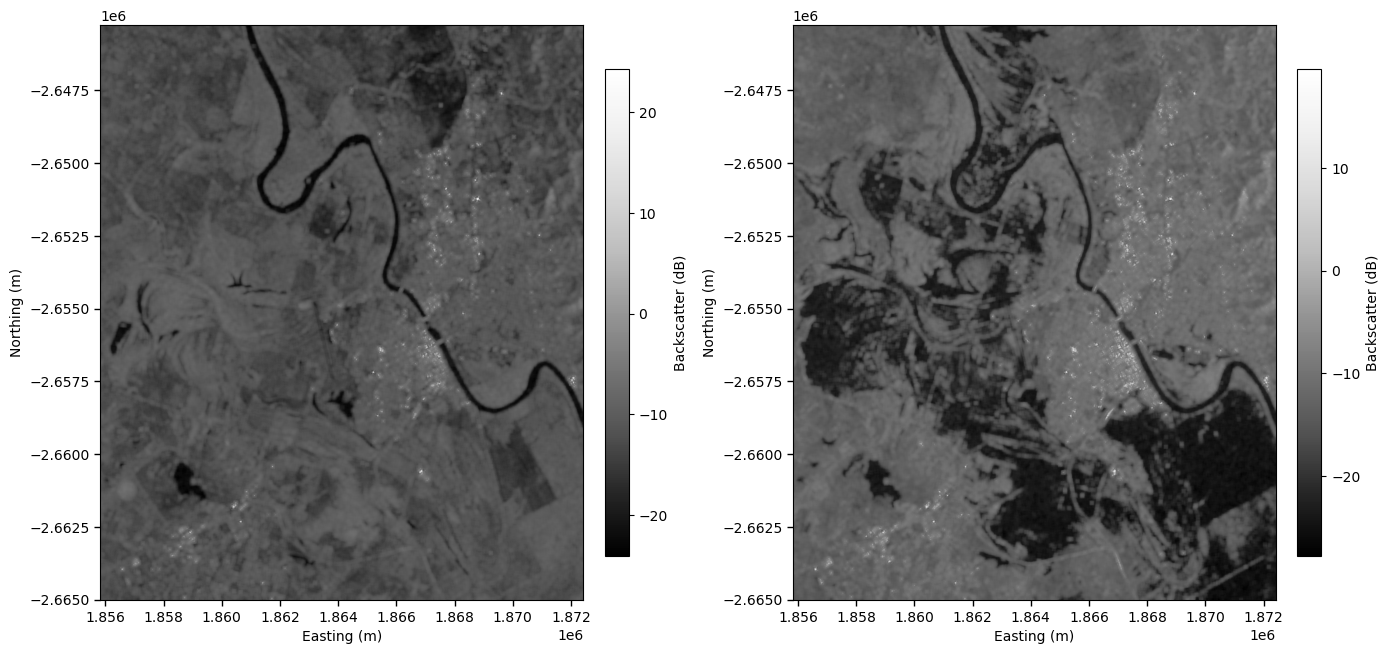

In [10]:
# Plot Lee-filtered VH rasters:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

for ax, img in zip(axes, vh_filtered_dB):
    cmap = plt.cm.Greys_r.copy()
    cmap.set_bad(color='black')  # set the NaNs in black
    im = ax.imshow(img, cmap=cmap, extent=extent, origin='upper')
    ax.set_xlabel("Easting (m)") # x-axis label
    ax.set_ylabel("Northing (m)") # y-axis label
    ax.tick_params(direction='out', length=4, width=1)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # add colourbar to show dB backscatter values
    cbar.set_label("Backscatter (dB)")

plt.tight_layout()

# Write plot as png to folder:
fig.savefig("vh_lee_filtered_georef_no_title.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Define Lee filter function - adapted from 'Radar_water_detection' ipynb in DEA Sandbox.
def lee_filter(img, size):
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2
    overall_variance = np.var(img)
    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

# Define the output name for teh VV rasters:
vv_rasters = [
    "vv_before_3577_20m_crop.tif",
    "vv_after_3577_20m_crop.tif"
]
names = ["Before", "After"]

# Read in the VV rasters:
vv_arrays = []
with rasterio.open(vv_rasters[0]) as src0:
    ref_transform = src0.transform
    height = src0.height
    width = src0.width

for path in vv_rasters:
    with rasterio.open(path) as src:
        vv_arrays.append(src.read(1))

# Apply Lee filter function and convert from DN to dB:
eps = 1e-4 # ad a small number to avoid the log of zero
size = 7 # the window size to determine how 'blurred' or 'smoothed' image becomes after applied filter.
vv_filtered_dB = [] # create empty list to store the filtered images in dB

# Use loop to apply Lee filter for both VH images:
for img in vv_arrays:
    filtered_linear = lee_filter(img, size=size)
    filtered_dB = 10 * np.log10(filtered_linear + eps)
    vv_filtered_dB.append(filtered_dB)

# Map filtered images to correct crs/extent:
extent = [
    ref_transform[2],
    ref_transform[2] + ref_transform[0]*width,
    ref_transform[5] + ref_transform[4]*height,
    ref_transform[5]
]

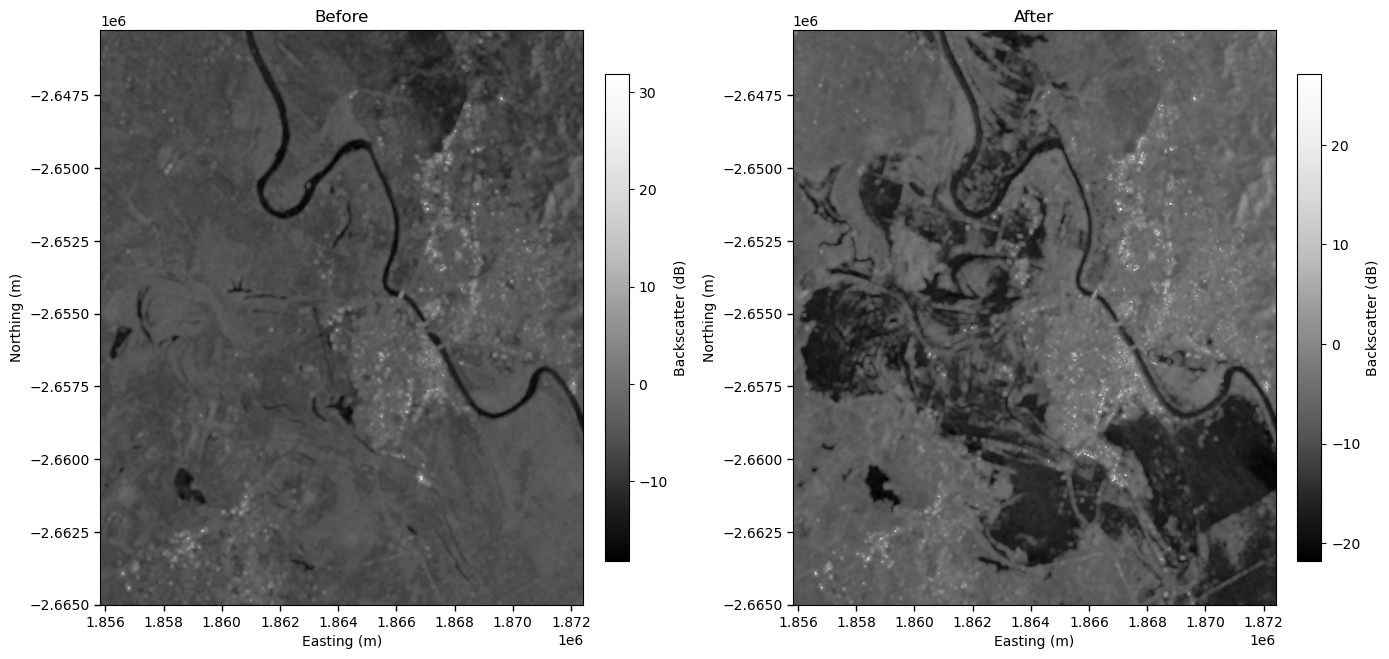

In [12]:
# Plot Lee-filtered VV rasters:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

for ax, img, title in zip(axes, vv_filtered_dB, names):
    cmap = plt.cm.Greys_r.copy()
    cmap.set_bad(color='black')  # make NaNs black
    im = ax.imshow(img, cmap=cmap, extent=extent, origin='upper')
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.tick_params(direction='out', length=4, width=1)
    ax.set_title(title) 
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # add colourbar to show backscatter dB values
    cbar.set_label("Backscatter (dB)")

plt.tight_layout()

# Write plot as png to folder:
fig.savefig("vv_lee_filtered_georef.png", dpi=300, bbox_inches='tight')
plt.show()

# VV Band will be used for analysis from here!

### Plot histograms to see effects of Lee filter on VV

In [14]:
# # First, stack all original images, BUT with converted DN to dB this time:
# all_images_dB = [10 * np.log10(arr + eps) for arr in vh_arrays + vv_arrays]
# # Then stack all Lee filtered images together:
# filtered_stack_dB = vh_filtered_dB + vv_filtered_dB
# Stack VH & VV original converted arrays
# vh_og_dB = [10 * np.log10(arr + eps) for arr in vh_arrays]
vv_og_dB = [10 * np.log10(arr + eps) for arr in vv_arrays]
# Stack by VH filtered and VV filtered
# vh_stack_filtered_dB = filtered_stack_dB[0:2]
vv_stack_filtered_dB = filtered_stack_dB[2:4]

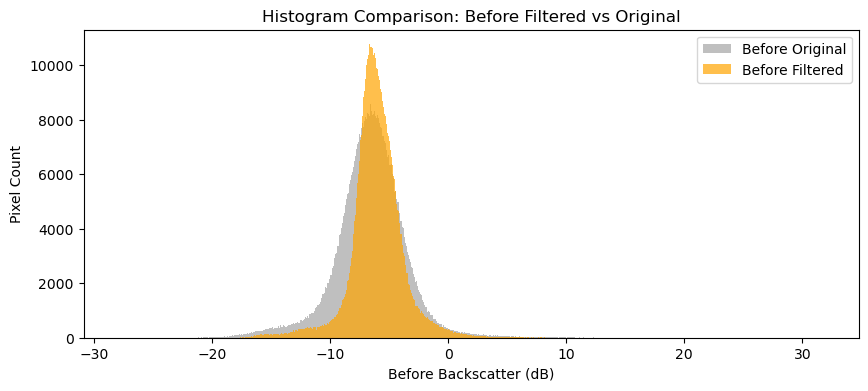

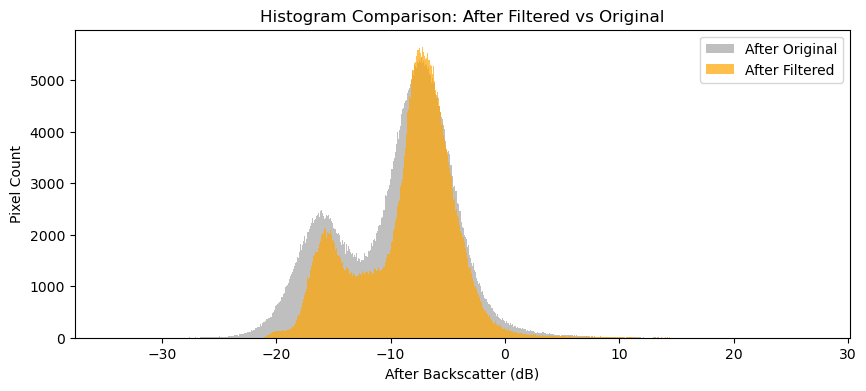

In [16]:
# Create histograms just for VV band (before/after):
for i, title in enumerate(names):
    orig = vv_og_dB[i]
    filt = vv_stack_filtered_dB[i]

    # Mask invalid pixels (0 or NaN)
    mask_orig = (~np.isnan(orig)) & (orig != 0)
    mask_filt = (~np.isnan(filt)) & (filt != 0)

    # Compute histograms to scale y-axis
    orig_hist, _ = np.histogram(orig[mask_orig].ravel(), bins=1000)
    filt_hist, _ = np.histogram(filt[mask_filt].ravel(), bins=1000)
    max_count = max(orig_hist.max(), filt_hist.max())

    # Plot histogram
    plt.figure(figsize=(10, 4))
    plt.hist(orig[mask_orig].ravel(), bins=1000, alpha=0.5, label=f"{title} Original", color='gray')
    plt.hist(filt[mask_filt].ravel(), bins=1000, alpha=0.7, label=f"{title} Filtered", color='orange')
    plt.xlabel(f"{title} Backscatter (dB)")
    plt.ylabel("Pixel Count")
    plt.title(f"Histogram Comparison: {title} Filtered vs Original")
    plt.ylim(0, max_count*1.05)
    plt.legend()
    plt.show()

### Apply Otsu threshold

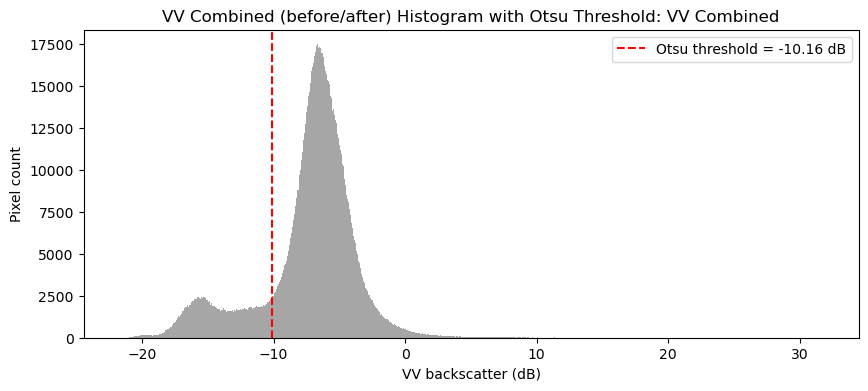

VV combined threshold: -10.155468


In [21]:
# Unstack filtered arrays:
vh_before_filt, vh_after_filt, vv_before_filt, vv_after_filt = filtered_stack_dB

# Define function for Otsu threshold (Otsu, 1979):
def otsu_threshold_plot_combined(img_list, label, band="VH"):
    # Stack the images into 1D array, mask NaN/zeros
    combined_data = np.concatenate([img[np.isfinite(img)][img[np.isfinite(img)] != 0] for img in img_list])
    
    # Calculate the Otsu threshold
    threshold = threshold_otsu(combined_data)
    
    # Plot a histogram with the threshold line:
    plt.figure(figsize=(10,4))
    plt.hist(combined_data.ravel(), bins=1000, color="gray", alpha=0.7)
    plt.axvline(threshold, color="red", linestyle="--", label=f"Otsu threshold = {threshold:.2f} dB")
    plt.xlabel(f"{band} backscatter (dB)")
    plt.ylabel("Pixel count")
    plt.title(f"{band} Combined (before/after) Histogram with Otsu Threshold: {label}")
    plt.legend()
    plt.show()
    
    return threshold

# # --- Run for VH (combined before+after) ---
# vh_threshold = otsu_threshold_plot_combined([vh_before_filt_dB, vh_after_filt_dB], label="VH Combined", band="VH")

# --- Run for VV (combined before+after) ---
vv_threshold = otsu_threshold_plot_combined([vv_before_filt_dB, vv_after_filt_dB], label="VV Combined", band="VV")

# print("VH combined threshold:", vh_threshold)
print("VV combined threshold:", vv_threshold)

In [22]:
# Update threshold for VV only:
# vh_threshold_otsu = -16.66286
vv_threshold_otsu = -10.155468

### Define water and non-water from Otsu thresholds

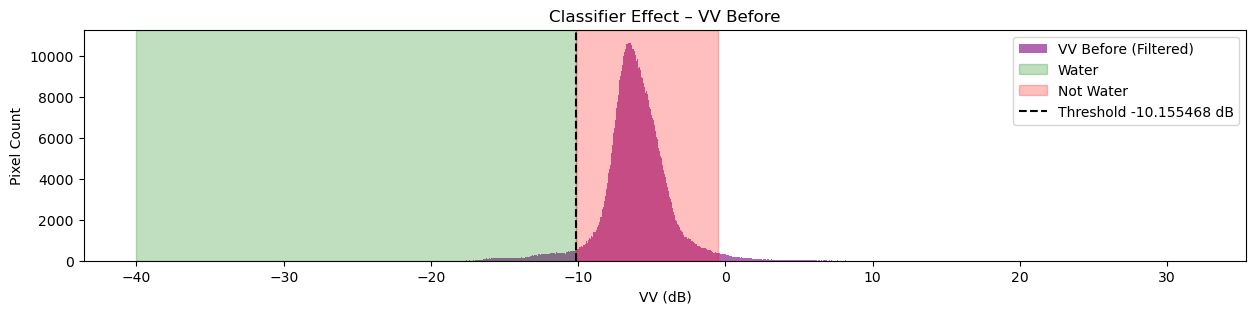

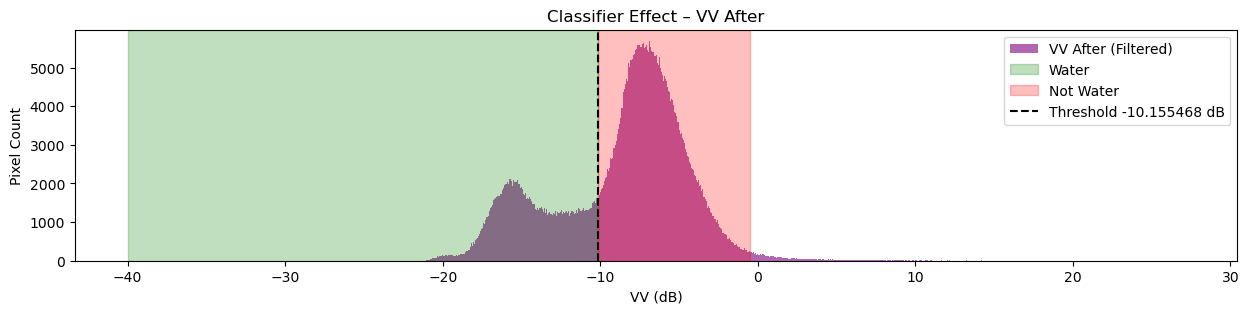

In [24]:
# Use plots to show where water is delineated from non-water (i.e., flood vs no flood)
# Adapted from 'Radar_water_detection' ipynb in DEA Sandbox.

# VV - before
fig, ax = plt.subplots(figsize=(15, 3))
ax.hist(vv_before_filt.ravel(), bins=1000, color="purple", alpha=0.6, label="VV Before (Filtered)")
ax.axvspan(-40.0, vv_threshold_otsu, alpha=0.25, color="green", label="Water")
ax.axvspan(vv_threshold_otsu, -0.5, alpha=0.25, color="red", label="Not Water")
ax.axvline(vv_threshold_otsu, color="black", linestyle="--", label=f"Threshold {vv_threshold_otsu} dB")
ax.set_xlabel("VV (dB)")
ax.set_ylabel("Pixel Count")
ax.set_title("Classifier Effect – VV Before")
ax.legend()
plt.show()
# Export
fig.savefig("vv_before_classifier_histogram.png", dpi=300, bbox_inches='tight')
plt.show()


# VV - after
fig, ax = plt.subplots(figsize=(15, 3))
ax.hist(vv_after_filt.ravel(), bins=1000, color="purple", alpha=0.6, label="VV After (Filtered)")
ax.axvspan(-40.0, vv_threshold_otsu, alpha=0.25, color="green", label="Water")
ax.axvspan(vv_threshold_otsu, -0.5, alpha=0.25, color="red", label="Not Water")
ax.axvline(vv_threshold_otsu, color="black", linestyle="--", label=f"Threshold {vv_threshold_otsu} dB")
ax.set_xlabel("VV (dB)")
ax.set_ylabel("Pixel Count")
ax.set_title("Classifier Effect – VV After")
ax.legend()
plt.show()

# Export
fig.savefig("vv_after_classifier_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

### Build and apply the classifier

In [27]:
# Define function for classifier
def create_water_mask(filtered_dB, threshold):
    # Mask zeros
    mask = np.zeros_like(filtered_dB, dtype=np.uint8)
    # Set water pixels (below threshold) to 1
    mask[(filtered_dB < threshold) & np.isfinite(filtered_dB)] = 1
    mask = mask.astype(np.uint8)
    return mask

# Apply the Otsu thresholds from before:
vv_before_mask = create_water_mask(vv_before_filt_dB, vv_threshold_otsu)
vv_after_mask  = create_water_mask(vv_after_filt_dB,  vv_threshold_otsu)

# Combine before and after:
vv_combined = ((vv_before_mask | vv_after_mask)).astype(np.uint8)

### Create binary flood maps
0 = Non-water  
1 = Water

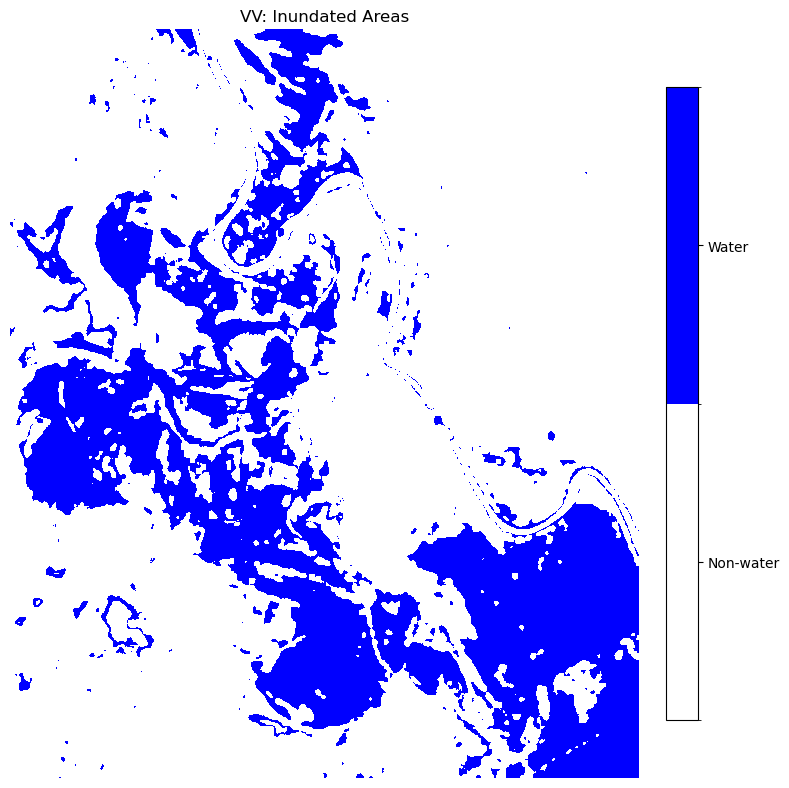

In [29]:
# Define binary colourmap: 0 = white (non-water), 1 = blue (water)
cmap = mcolors.ListedColormap(['white', 'blue'])
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

im = ax.imshow(vv_new_water, cmap=cmap, norm=norm)
ax.set_title("Inundated Areas")
ax.axis("off")

# Add colourbar
cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['Non-water', 'Water'])

plt.tight_layout()
plt.show()


### Create flood map with Before & After Cyclone water extent

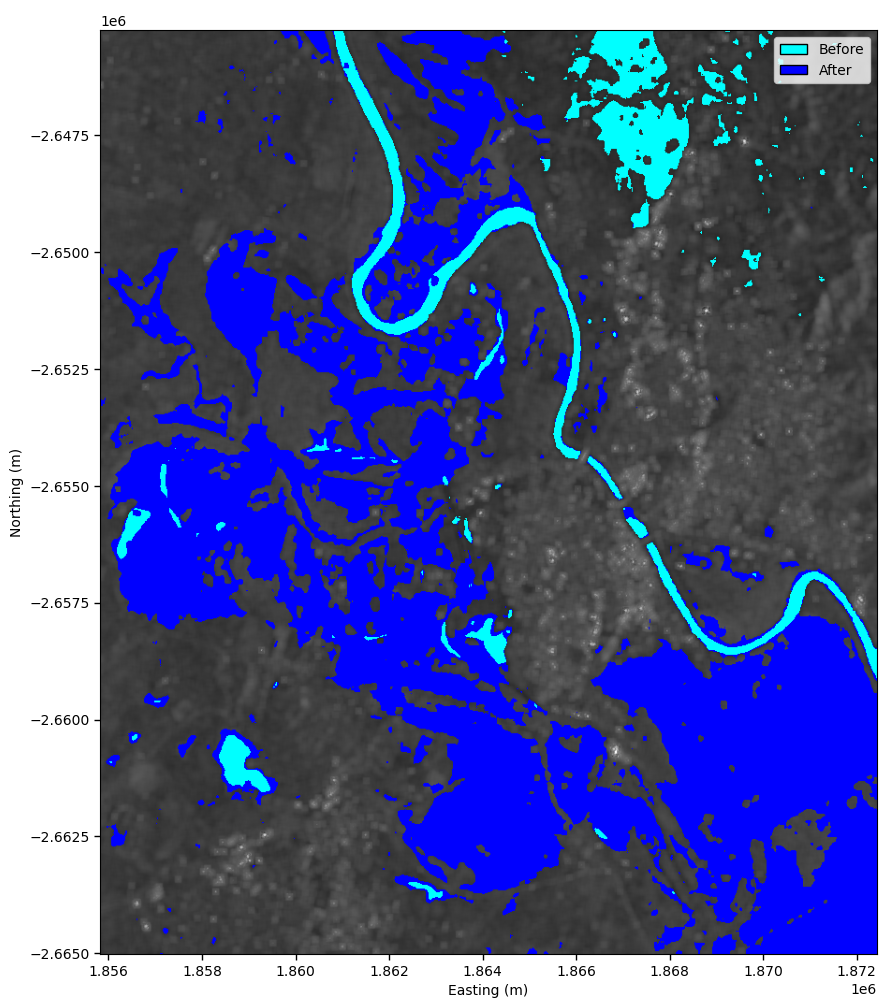

In [34]:
# Quick define georeference extent:
x_min = ref_transform[2]
y_max = ref_transform[5]
height, width = vv_before_filt_dB.shape
x_max = x_min + ref_transform[0] * width
y_min = y_max + ref_transform[4] * height
extent = [x_min, x_max, y_min, y_max]

# Take the Lee filtered 'before' VV image and greyscale it to put in the background:
greyscale = np.stack([vv_before_filt_dB, vv_before_filt_dB, vv_before_filt_dB], axis=-1)
greyscale_min, greyscale_max = np.nanmin(vv_before_filt_dB), np.nanmax(vv_before_filt_dB)
greyscale = (greyscale - greyscale_min) / (greyscale_max - greyscale_min)

# Existing water = cyan
greyscale[(vv_before_mask == 1) & (vv_new_water    == 0)] = [0, 1, 1]

# Flooded areas = blue
greyscale[vv_new_water    == 1] = [0, 0, 1]

# Plot binary map showing before/after flood extent on top of greyscale:
fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(rgb, extent=extent, origin='upper')
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.tick_params(direction='out', length=4, width=1)
ax.set_title("  ")

# Legend
legend_elements = [
    Patch(facecolor='cyan', edgecolor='k', label='Before'),
    Patch(facecolor='blue', edgecolor='k', label='After')
]
ax.legend(handles=legend_elements, loc='upper right')

# # --- Export ---
# fig.savefig(export_name, dpi=300, bbox_inches='tight')
# plt.show()


## Validation Section

### Write in QLD Gov Cyclone Debbie Flood Shapefile
Dataset derived from: https://qldspatial.information.qld.gov.au/catalogue/custom/viewMetadataDetails.page?uuid={EFB94092-5193-4781-A012-069B6F943E2F}  
Queensland Government. (2017). Flood extent polygon - April 2017 - Connors Fitzroy Isaac and Mackenzie Rivers [Metadata record]. QSpatial Catalogue.   

- Reproject to Australian Albers
- Resample to 20m resolution
- Crop to study extent

In [40]:
# Open reference flood dataset polygon:
extract_folder = "Flood_extent_polygon_GDA94"
shp_path = os.path.join(extract_folder, "Flood_extent_polygon_GDA94.shp")

# Load & reproject to EPSG:3577
flood_gdf = gpd.read_file(shp_path).to_crs(epsg=3577)

# Open reference raster (using vv:
ref_raster_path = "vv_after_3577_20m_crop.tif"  # just need one to compare and copy
with rasterio.open(ref_raster_path) as ref_src:
    ref_meta = ref_src.meta.copy()
    ref_shape = ref_src.shape
    ref_transform = ref_src.transform

# Rasterize shapefile to match reference raster:
ref_flood_raster = rasterize(
    [(geom, 1) for geom in flood_gdf.geometry],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype="uint8"
)

# # Write rasterized flood extent into folder:
# out_raster_path = "flood_extent_debbie_rasterized.tif"
# ref_meta.update(dtype="uint8", count=1)
# with rasterio.open(out_raster_path, "w", **ref_meta) as dst:
#     dst.write(ref_flood_raster, 1)

# print(f"Rasterized flood extent saved to: {out_raster_path}")


### Check SAR flood classification and reference dataset have same shape

In [41]:
# Check that VV SAR images and rasterized shapefile havet he same shape:
print("Flood raster shape:", ref_flood_raster.shape)
print("VV mask shape:", vv_new_water.shape)

# Quick check if all match
if ref_flood_raster.shape == vv_new_water.shape:
    print("Arrays have the same shape — ready for accuracy assessment.")
else:
    print("Shape mismatch! You need to align or resample arrays first.")


Flood raster shape: (988, 830)
VV mask shape: (988, 830)
Arrays have the same shape — ready for accuracy assessment.


### Compare SAR flood classifications to QLD Gov reference dataset
Produce a confusion matrix with:  
- Overall accuracy
- Kappa
- Producer Accuracy
- User Accuracy

In [44]:
# Define function for accuracy assessment:
def accuracy_assess(y_true, y_pred): # reference flood dataset values & my VV flood classification values (both binary 0/1)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel() 
    overall_acc = (TP + TN) / (TP + TN + FP + FN) # formula for overall accuracy
    kappa = cohen_kappa_score(y_true, y_pred) # kappa calc
    producer_acc = [TN/(TN+FP), TP/(TP+FN)]  # producers accuracy calc where matrix is = [Non-flood, Flood]
    user_acc = [TN/(TN+FN), TP/(TP+FP)]      # users accuracy calc where matrix is = [Non-flood, Flood]
    return {
        "Confusion Matrix": cm,
        "Overall Accuracy": overall_acc,
        "Kappa": kappa,
        "Producer Accuracy": producer_acc,
        "User Accuracy": user_acc
    }

# Flatten arrays for comparison:
y_true_vv = ref_flood_raster.ravel()
y_pred_vv = vv_new_water.ravel()

# VV Accuracy Assessment Results:
metrics_vv = accuracy_assess(y_true_vv, y_pred_vv)
print("VV Accuracy Assessment:")
print("Confusion Matrix:\n", metrics_vv["Confusion Matrix"])
print(f"Overall Accuracy: {metrics_vv['Overall Accuracy']:.3f}")
print(f"Kappa: {metrics_vv['Kappa']:.3f}")
print(f"Producer Accuracy [Non-flood, Flood]: {metrics_vv['Producer Accuracy']}")
print(f"User Accuracy [Non-flood, Flood]: {metrics_vv['User Accuracy']}")

VV Accuracy Assessment:
Confusion Matrix:
 [[420765   2399]
 [180279 216597]]
Overall Accuracy: 0.777
Kappa: 0.548
Producer Accuracy [Non-flood, Flood]: [0.9943308031874167, 0.5457548453421219]
User Accuracy [Non-flood, Flood]: [0.7000569009922735, 0.989045462017571]


### Overlay QLD Gov flood dataset on SAR flood map

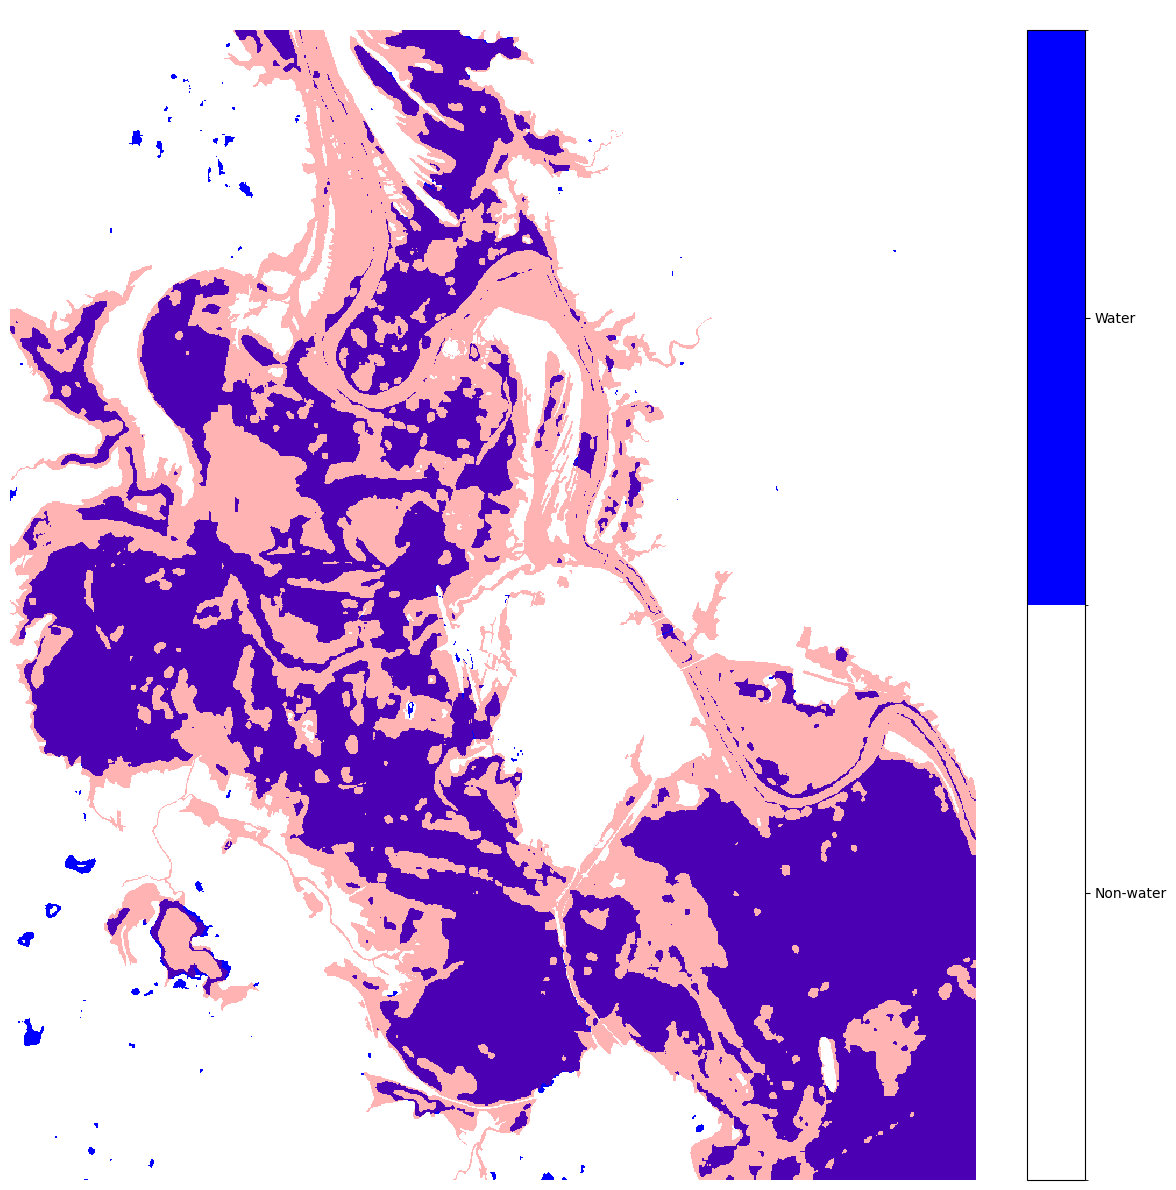

In [48]:
# Define binary colourmap for SAR flood mask:
sar_cmap = mcolors.ListedColormap(['white', 'blue'])
sar_norm = mcolors.BoundaryNorm([0, 0.5, 1], sar_cmap.N)

# Define a pink overlay for the reference flood dataset:
ref_cmap = mcolors.ListedColormap(['none', 'red']) 
ref_alpha = 0.3

# Define the study extent from a reference raster (ref_flood_raster):
extent = [
    ref_transform[2],                         # left
    ref_transform[2] + ref_transform[0]*flood_raster.shape[1],  # right
    ref_transform[5] + ref_transform[4]*flood_raster.shape[0],  # bottom
    ref_transform[5]                             # top
]

# Plot VV flood classification with refrence dataset overlay:
fig, ax = plt.subplots(figsize=(14, 12))

# SAR water mask
im = ax.imshow(vv_new_water, cmap=sar_cmap, norm=sar_norm,
               extent=extent, origin='upper')

# Reference flood overlay
ax.imshow(flood_raster, cmap=ref_cmap, alpha=ref_alpha,
          extent=extent, origin='upper')

ax.set_title("  ")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.axis('off')

# Add colourbar:
cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['Non-water', 'Water'])

plt.tight_layout()
plt.show()

### Calculate area of flood inundation - Before Cyclone

In [56]:
# Determine pixel area:
# Pixel size from reference raster transform"
pixel_width = ref_transform[0] 
pixel_height = abs(ref_transform[4])
pixel_area_m2 = pixel_width * pixel_height

# For reference QLD dataset:
flooded_pixels_ref = np.sum(flood_raster == 1)

# Count flooded pixels:
flooded_pixels_vv_before = np.sum(vv_before_mask == 1)
flooded_pixels_vv = np.sum(vv_new_water == 1)
flood_area_m2_ref = flooded_pixels_ref * pixel_area_m2

# Calculare area in m²:
flood_area_m2_vv_before = flooded_pixels_vv_before * pixel_area_m2
flood_area_m2_vv = flooded_pixels_vv * pixel_area_m2
flood_area_m2_ref = flooded_pixels_ref * pixel_area_m2

# Convert m² to km²:
flood_area_km2_vv_before = flood_area_m2_vv_before / 1000000
flood_area_km2_vv = flood_area_m2_vv / 1000000
flood_area_km2_ref = flood_area_m2_ref / 1000000

# Print results of area change:
print(f"VV Water Area BEFORE cyclone: {flood_area_km2_vv_before:.2f} km² ")
print(f"VV Flood Area AFTER cyclone: {flood_area_km2_vv:.2f} km²")
print(f"Flood reference data: {flood_area_km2_ref:.2f} km²")

VV Water Area BEFORE cyclone: 12.63 km² 
VV Flood Area AFTER cyclone: 87.60 km²
Flood reference data: 158.75 km²
